# UNet Semantic Segmentation — Oxford-IIIT Pet

Pipeline: dataset → UNet (Keras) → train → evaluate → export TFLite

**Run this notebook on the GPU machine.**

## 1. Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset

In [2]:
IMG_SIZE = 256
BATCH_SIZE = 16
SUBSET_SIZE = 1000  # use a subset for faster training

def preprocess(sample):
    image = tf.image.resize(sample['image'], (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0

    # Mask values: 1=pet, 2=background, 3=outline → shift to 0-indexed
    mask = tf.image.resize(sample['segmentation_mask'], (IMG_SIZE, IMG_SIZE), method='nearest')
    mask = tf.cast(mask, tf.int32) - 1  # now 0=pet, 1=background, 2=outline
    return image, mask

(ds_train_raw, ds_val_raw), info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True
)

ds_train = (
    ds_train_raw
    .take(SUBSET_SIZE)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(500)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_val = (
    ds_val_raw
    .take(200)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f'Train batches: {len(ds_train)}, Val batches: {len(ds_val)}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ON08YG_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ON08YG_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Train batches: 63, Val batches: 13


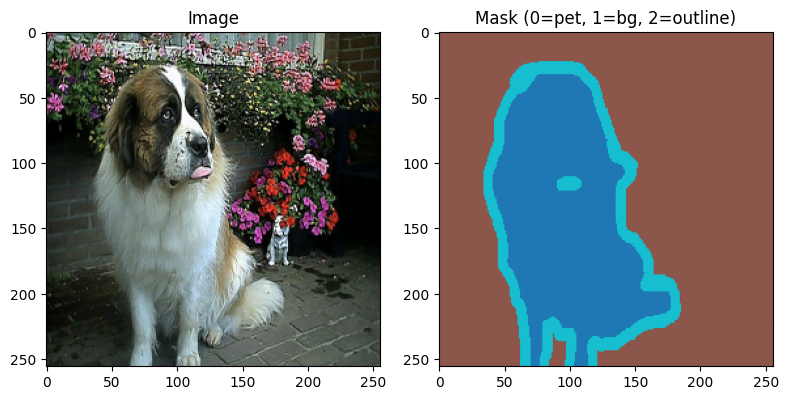

In [3]:
# Quick sanity check — visualize one sample
for image, mask in ds_train.take(1):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(image[0])
    axes[0].set_title('Image')
    axes[1].imshow(mask[0, :, :, 0], cmap='tab10', vmin=0, vmax=2)
    axes[1].set_title('Mask (0=pet, 1=bg, 2=outline)')
    plt.tight_layout()
    plt.show()

## 3. UNet Model

In [4]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def encoder_block(x, filters):
    skip = conv_block(x, filters)
    x = layers.MaxPooling2D()(skip)
    return x, skip

def decoder_block(x, skip, filters):
    x = layers.UpSampling2D()(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x, s1 = encoder_block(inputs, 64)
    x, s2 = encoder_block(x, 128)
    x, s3 = encoder_block(x, 256)
    x, s4 = encoder_block(x, 512)

    # Bottleneck
    x = conv_block(x, 1024)

    # Decoder
    x = decoder_block(x, s4, 512)
    x = decoder_block(x, s3, 256)
    x = decoder_block(x, s2, 128)
    x = decoder_block(x, s1, 64)

    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)
    return Model(inputs, outputs, name='unet')

model = build_unet()
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,379,075 (119.70 MB)

 Trainable params: 31,379,075 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training

In [5]:
os.makedirs('../models', exist_ok=True)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        '../models/unet_best.keras',
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        monitor='val_loss',
        restore_best_weights=True
    )
]

history = model.fit(
    ds_train,
    epochs=30,
    validation_data=ds_val,
    callbacks=callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5520 - loss: 3.1049   
Epoch 1: val_loss improved from None to 0.96776, saving model to ../models/unet_best.keras

Epoch 1: finished saving model to ../models/unet_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.5832 - loss: 1.6064 - val_accuracy: 0.5838 - val_loss: 0.9678
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.5943 - loss: 0.9239
Epoch 2: val_loss improved from 0.96776 to 0.85225, saving model to ../models/unet_best.keras

Epoch 2: finished saving model to ../models/unet_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 909ms/step - accuracy: 0.5930 - loss: 0.9067 - val_accuracy: 0.5836 - val_loss: 0.8522
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.6197 - loss: 0.8501
Epoch 3: val_loss improved from 0.85225 to 0.75721, saving model to ../models/unet_best.keras

Epoch 3: finished saving model to ../models/unet_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 943ms/step - ac

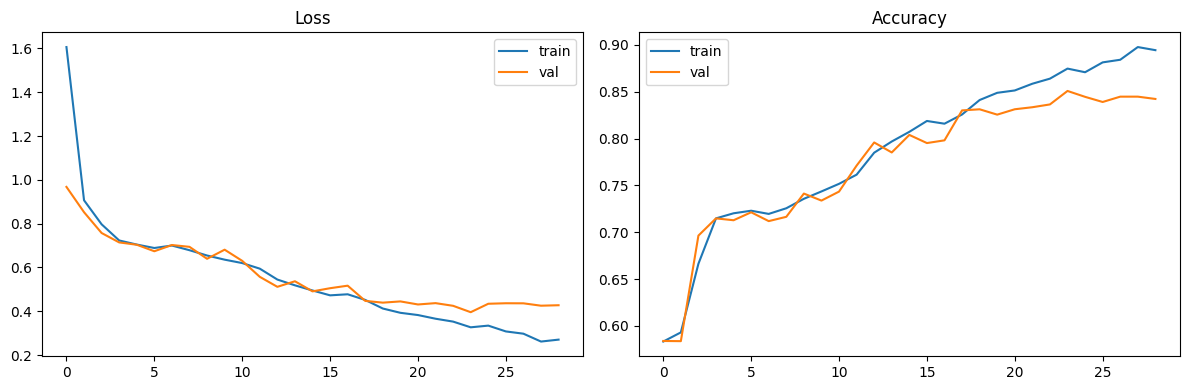

In [6]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Evaluation

In [7]:
best_model = tf.keras.models.load_model('../models/unet_best.keras')

iou_metric = tf.keras.metrics.MeanIoU(num_classes=3)
acc_metric = tf.keras.metrics.Accuracy()

for images, masks in ds_val:
    preds = best_model.predict(images, verbose=0)          # (B, 256, 256, 3)
    pred_classes = tf.argmax(preds, axis=-1)               # (B, 256, 256)
    true_classes = tf.squeeze(masks, axis=-1)              # (B, 256, 256)
    iou_metric.update_state(true_classes, pred_classes)
    acc_metric.update_state(true_classes, pred_classes)

print(f'Mean IoU:  {iou_metric.result().numpy():.4f}')
print(f'Accuracy:  {acc_metric.result().numpy():.4f}')

Mean IoU:  0.6481
Accuracy:  0.8509


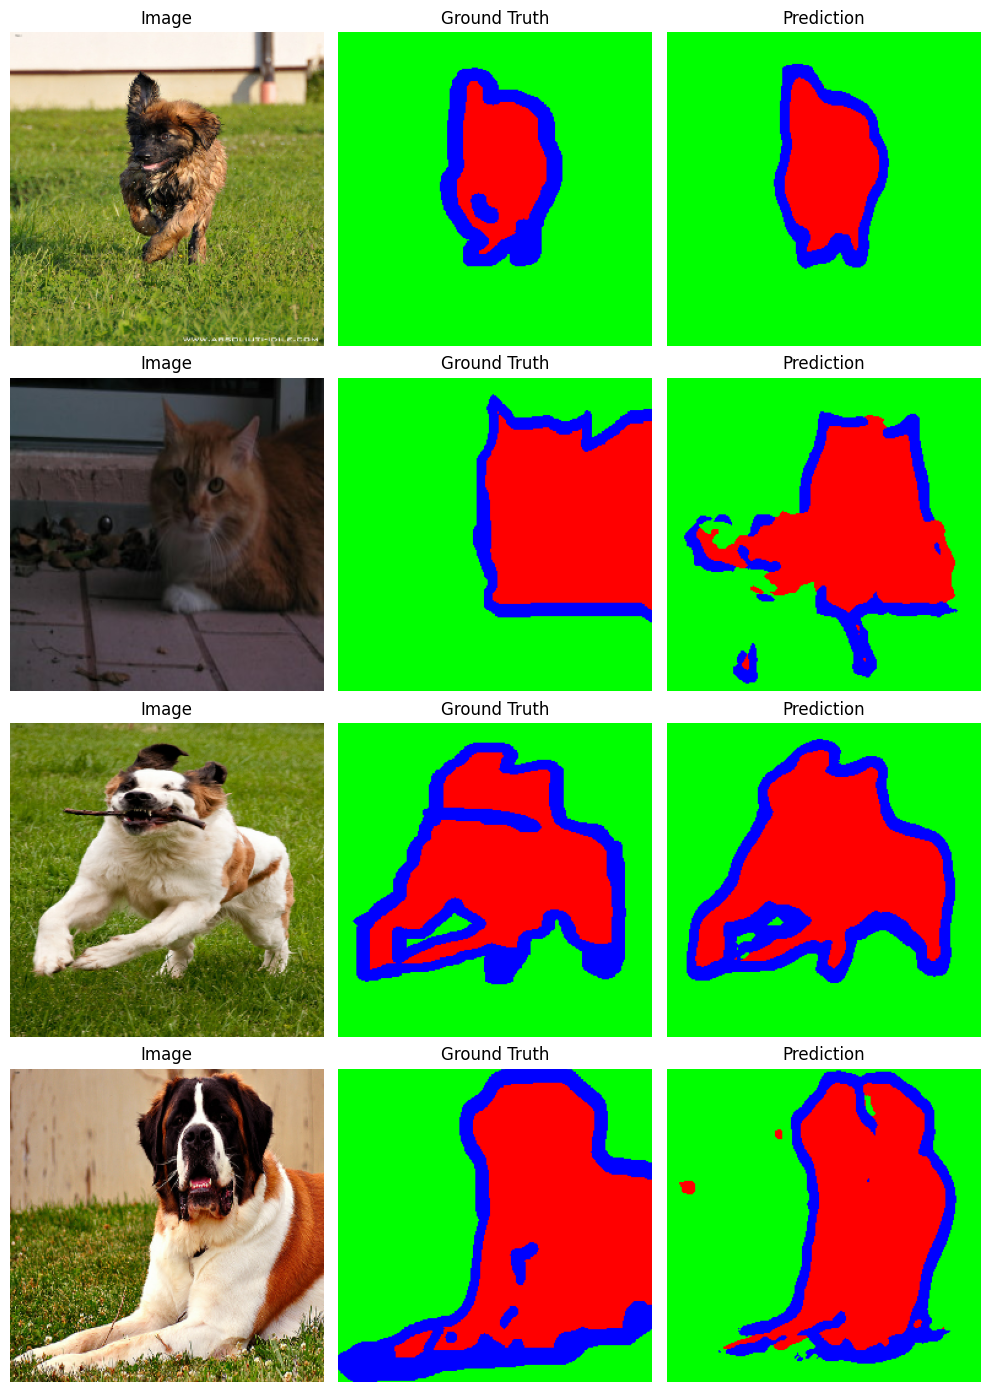

In [8]:
# Visualize predictions on a few samples
CLASS_COLORS = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255]], dtype=np.uint8)  # pet=red, bg=green, outline=blue

for images, masks in ds_val.take(1):
    preds = best_model.predict(images[:4], verbose=0)
    pred_classes = tf.argmax(preds, axis=-1).numpy()   # (4, 256, 256)
    true_classes = tf.squeeze(masks[:4], axis=-1).numpy()

    fig, axes = plt.subplots(4, 3, figsize=(10, 14))
    for i in range(4):
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title('Image')
        axes[i, 1].imshow(CLASS_COLORS[true_classes[i]])
        axes[i, 1].set_title('Ground Truth')
        axes[i, 2].imshow(CLASS_COLORS[pred_classes[i]])
        axes[i, 2].set_title('Prediction')
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.show()

## 6. TFLite Export

In [9]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
# FP32 — no quantization (as required by the spec)
tflite_model = converter.convert()

tflite_path = '../models/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / 1024 / 1024
print(f'Exported: {tflite_path} ({size_mb:.1f} MB)')

Saved artifact at '/tmp/tmpa2jpar9f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None)
Captures:
  138647631680656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138647631681040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138647631681232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138647631680464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138647631677200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138647631681808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138650341400336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138650341399376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138650341400720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138650341400528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13865

In [10]:
# Verify the TFLite model works
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input shape: ', input_details[0]['shape'])   # should be [1, 256, 256, 3]
print('Output shape:', output_details[0]['shape'])  # should be [1, 256, 256, 3]
print('Input dtype: ', input_details[0]['dtype'])

# Run one inference
for images, _ in ds_val.take(1):
    test_input = images[0:1].numpy().astype(np.float32)  # (1, 256, 256, 3)
    interpreter.set_tensor(input_details[0]['index'], test_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])  # (1, 256, 256, 3)
    print('Output sample (argmax):', np.argmax(output[0], axis=-1)[:3, :3])
    print('TFLite inference OK')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input shape:  [  1 256 256   3]
Output shape: [  1 256 256   3]
Input dtype:  <class 'numpy.float32'>
Output sample (argmax): [[1 1 1]
 [1 1 1]
 [1 1 1]]
TFLite inference OK


## Done

Copy `models/model.tflite` to the Android project:
```
android/app/src/main/assets/model.tflite
```